Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.8999 - loss: 0.3244 - val_accuracy: 0.9855 - val_loss: 0.0550
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9842 - loss: 0.0498 - val_accuracy: 0.9887 - val_loss: 0.0402
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.9889 - loss: 0.0335 - val_accuracy: 0.9882 - val_loss: 0.0427

Evaluating the model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9853 - loss: 0.0486
Test Accuracy: 0.9878

Visualizing feature maps for a sample image...
Layers in model: ['conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1', 'flatten', 'dense', 'dense_1']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


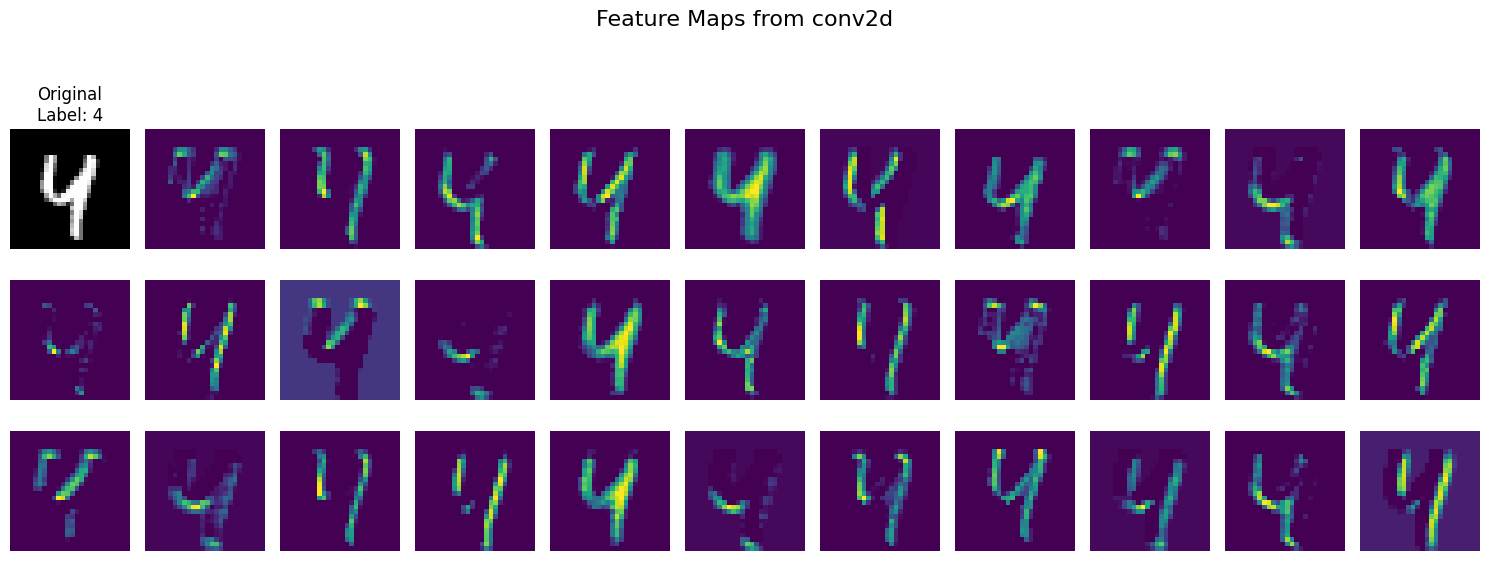

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


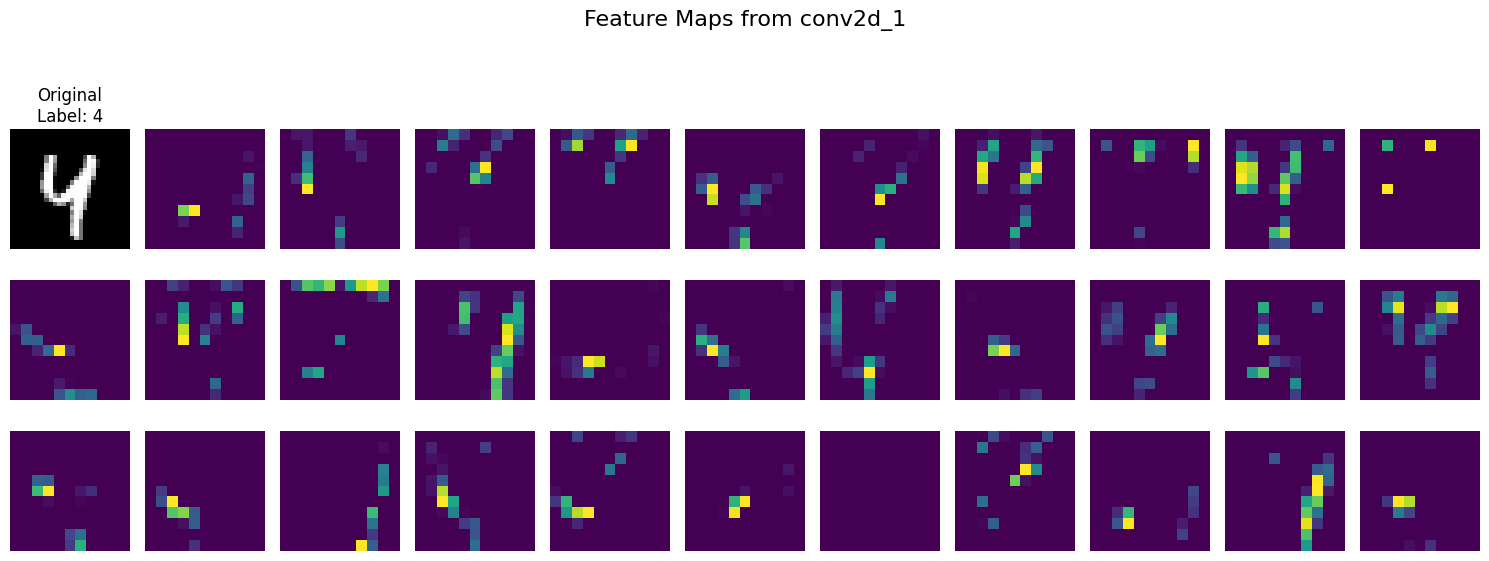

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, models, layers, Input
import matplotlib.pyplot as plt

# --- 1. Load and Preprocess the Data ---
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Add channel dimension (28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# --- 2. Build the CNN Model ---
model = models.Sequential(name="MNIST_CNN")

# Explicit Input layer fixes issues with accessing model.input later
model.add(Input(shape=(28, 28, 1), name="input_layer"))

model.add(layers.Conv2D(32, (3, 3), activation='relu', name="conv2d"))
model.add(layers.MaxPooling2D((2, 2), name="max_pooling2d"))

model.add(layers.Conv2D(64, (3, 3), activation='relu', name="conv2d_1"))
model.add(layers.MaxPooling2D((2, 2), name="max_pooling2d_1"))

model.add(layers.Flatten(name="flatten"))
model.add(layers.Dense(64, activation='relu', name="dense"))
model.add(layers.Dense(10, activation='softmax', name="dense_1"))

model.summary()

# --- 3. Compile & Train ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\nTraining the model...")
history = model.fit(X_train, y_train, epochs=3, validation_split=0.1, verbose=1)

# --- 4. Evaluate ---
print("\nEvaluating the model...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")

# --- 5. Visualize Feature Maps ---
print("\nVisualizing feature maps for a sample image...")

# Check available layer names
print("Layers in model:", [layer.name for layer in model.layers])

# Select a sample image
sample_image_index = 42
sample_image = X_test[sample_image_index]
true_label = y_test[sample_image_index]
sample_image_reshaped = np.expand_dims(sample_image, axis=0)

# Function to plot feature maps
def plot_feature_maps(layer_name, sample_image, true_label):
    # Create a model that outputs the activations of the specified layer
    intermediate_model = models.Model(inputs=model.inputs,
                                      outputs=model.get_layer(layer_name).output)
    feature_maps = intermediate_model.predict(sample_image)

    plt.figure(figsize=(15, 6))
    plt.subplot(3, 11, 1)
    plt.imshow(sample_image[0, :, :, 0], cmap='gray')
    plt.title(f"Original\nLabel: {true_label}")
    plt.axis('off')

    num_filters = feature_maps.shape[-1]
    for i in range(min(num_filters, 32)):  # show first 32 filters
        plt.subplot(3, 11, i + 2)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Feature Maps from {layer_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Visualize from both Conv2D layers
plot_feature_maps("conv2d", sample_image_reshaped, true_label)
plot_feature_maps("conv2d_1", sample_image_reshaped, true_label)

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 54.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.58MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]


CNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch 1: Train acc=0.9309, Val acc=0.9788
Epoch 2: Train acc=0.9799, Val acc=0.9855
Epoch 3: Train acc=0.9853, Val acc=0.9875
Epoch 4: Train acc=0.9883, Val acc=0.9887
Epoch 5: Train acc=0.9895, Val acc=0.9885
Epoch 6: Train acc=0.9916, Val acc=0.9880
Epoch 7: Train acc=0.9928, Val acc=0.9892
Epoch 8: Train acc=0.9928, Val acc=0.9890
Epoch 9: Train acc=0.9939, Val acc=0.9902
Epoch 10: Train acc

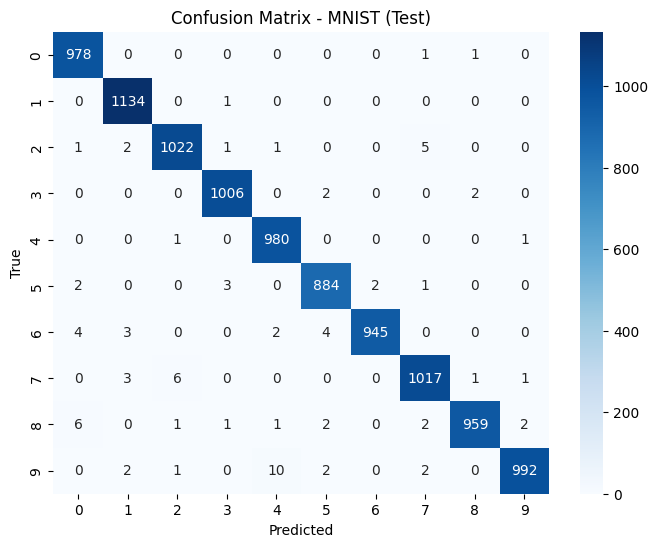

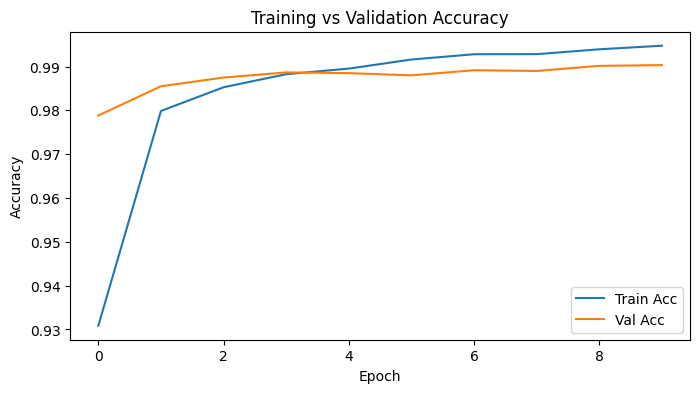

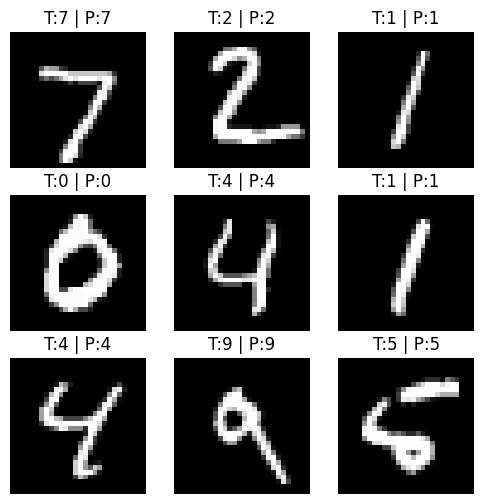

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# CONFIG
SEED = 42
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)
# DATASET AND DATALOADER
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST normalization
])

# Load MNIST dataset
train_val_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Split train into train/val
train_size = int(0.9 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# DEFINE CNN MODEL
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 7x7
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = CNN().to(DEVICE)
print(model)
# LOSS AND OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
# TRAINING AND EVALUATION FUNCTIONS
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_all, targets_all = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            targets_all.extend(y.cpu().numpy())
    return total_loss/total, correct/total, np.array(preds_all), np.array(targets_all)
    # RUN TRAINING
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader)
    vl, va, _, _ = evaluate(model, val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta); val_accs.append(va)
    print(f"Epoch {epoch}: Train acc={ta:.4f}, Val acc={va:.4f}")
    # TEST EVALUATION
test_loss, test_acc, test_preds, test_targets = evaluate(model, test_loader)
print(f"\n✅ Test accuracy: {test_acc:.4f}")

# Classification report
print("\nClassification Report:\n", classification_report(test_targets, test_preds, digits=4))
# CONFUSION MATRIX
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MNIST (Test)")
plt.show()
# ACCURACY CURVES
plt.figure(figsize=(8,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()
#SAMPLE PREDICTIONS
images, labels = next(iter(test_loader))
images, labels = images[:9], labels[:9]

with torch.no_grad():
    outputs = model(images.to(DEVICE))
    preds = outputs.argmax(1).cpu()

fig, axes = plt.subplots(3, 3, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i][0], cmap="gray")
    ax.set_title(f"T:{labels[i]} | P:{preds[i]}")
    ax.axis("off")
plt.show()